In [1]:
import random

from sklearn.metrics import confusion_matrix, classification_report
# Сторонние библиотеки
import numpy as np  # библиотека функций для работы с матрицами

""" ---Раздел описаний--- """
""" --Описание класса Network--"""


class Network(object):  # используется для описания нейронной сети
    def __init__(self, sizes):  # конструктор класса
        # self – указатель на объект класса
        # sizes – список размеров слоев нейронной сети
        self.num_layers = len(sizes)  # задаем количество слоев нейронной сети
        self.sizes = sizes  # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]  # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in
                        zip(sizes[:-1], sizes[1:])]  # задаем случайные начальные веса связей

    def sigmoid(self, z):  # определение сигмоидальной функции активации
        return 1.0 / (1.0 + np.exp(-z))

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a) + b)
        return a

    def SGD(  # Стохастический градиентный спуск
            self  # указатель на объект класса
            , training_data  # обучающая выборка
            , epochs  # количество эпох обучения
            , mini_batch_size  # размер подвыборки
            , eta  # скорость обучения
            , test_data  # тестирующая выборка
    ):
        test_data = list(test_data)  # создаем список объектов тестирующей выборки
        n_test = len(test_data)  # вычисляем длину тестирующей выборки
        training_data = list(training_data)  # создаем список объектов обучающей выборки
        n = len(training_data)  # вычисляем размер обучающей выборки
        for j in range(epochs):  # цикл по эпохам
            random.shuffle(training_data)  # перемешиваем элементы обучающей выборки
            mini_batches = [training_data[k:k + mini_batch_size] for k in
                            range(0, n, mini_batch_size)]  # создаем подвыборки
            for mini_batch in mini_batches:  # цикл по подвыборкам
                #print(len(mini_batch[0][0]))
                self.update_mini_batch(mini_batch, eta)  # один шаг градиентного спуска
            print("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test))  # смотрим прогресс в обучении

    def update_mini_batch(  # Шаг градиентного спуска
            self  # указатель на объект класса
            , mini_batch  # подвыборка
            , eta  # скорость обучения
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,
                                                         y)  # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b,
                                                   delta_nabla_b)]  # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w,
                                                   delta_nabla_w)]  # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in
                        zip(self.weights, nabla_w)]  # обновляем все веса w нейронной сети
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in
                       zip(self.biases, nabla_b)]  # обновляем все смещения b нейронной сети

    def backprop(  # Алгоритм обратного распространения
            self  # указатель на объект класса
            , x  # вектор входных сигналов ,
            , y  # ожидаемый вектор выходных сигналов
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x  # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [
            x]  # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = []  # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b  # считаем активационные потенциалы текущего слоя
            zs.append(z)  # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(
                z)  # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation)  # добавляем элемент (выходные сигналы слоя) в конец списка
        # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(
            zs[-1])  # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta  # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())  # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
            z = zs[-l]  # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
            sp = self.sigmoid_prime(z)  # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
            delta = np.dot(self.weights[-l + 1].transpose(),
                           delta) * sp  # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
            nabla_b[-l] = delta  # градиент dC/db для l-го слоя (BP3)
            nabla_w[-l] = np.dot(delta, activations[-l - 1].transpose())  # градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):  # Оценка прогресса в обучении
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations,
                        y):  # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
        return (output_activations - y)

    def sigmoid_prime(self, z):  # Производная сигмоидальной функции
        return self.sigmoid(z) * (1 - self.sigmoid(z))


In [2]:
import numpy as np  # библиотека для работы с матрицами


def load_data(path, n):
    with np.load(path) as f:
        (x_train, y_train) = f['x_train'][:n], f['y_train'][:n]
        (x_test, y_test) = f['x_test'], f['y_test']
    return ((x_train, y_train), (x_test, y_test))


(x_train, y_train), (x_test, y_test) = load_data('mnist.npz', 60000)

X_train = []
thresholdedData = []
for i in range(len(x_train)):
    row = np.reshape(x_train[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_train.append(thresholdedData)

X_test = []
thresholdedData = []
for i in range(len(x_test)):
    row = np.reshape(x_test[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_test.append(thresholdedData)

In [3]:
def load_data_wrapper(n, load='mnist.npz'):
    #tr_d, te_d = load_data(path) # инициализация наборов данных в формате MNIST
    (x_train, y_train), (x_test, y_test) = load_data(load, n)
    training_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                       (x_train)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    training_results = [vectorized_result(y) for y in
                        (y_train)]  # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    training_data = list(zip(training_inputs, training_results))  # формируем набор обучающих данных из пар (x, y)
    # validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    # validation_data = zip(validation_inputs, va_d[1]) # формируем набор данных проверки из пар (x, y)
    test_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                   (x_test)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    #test_results = [vectorized_result(y) for y in (y_test)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    test_data = list(zip(test_inputs, y_test))  # формируем набор тестовых данных из пар (x, y)
    return (training_data, test_data)


In [4]:
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

(array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]

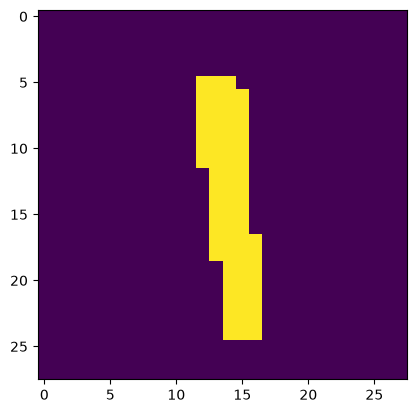

In [5]:
import matplotlib.pyplot as plt

training_data, test_data = load_data_wrapper(50000)
print(training_data[8])
lll8 = np.reshape(training_data[8][0], (28, 28))
plt.imshow(lll8)
plt.show()

Создайте нейронную сеть для распознавания рукописных цифр:


In [6]:
net = Network([784, 30, 10])
""" Вывод результата на экран: """
print('Сеть net:')
print('Количетво слоев:', net.num_layers)
for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])
for i in range(net.num_layers - 1):
    print('W_', i + 1, ':')
    print(np.round(net.weights[i], 2))
    print('b_', i + 1, ':')
    print(np.round(net.biases[i], 2))


Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 30
Количество нейронов в слое 2 : 10
W_ 1 :
[[ 0.62 -0.82  0.14 ...  0.44 -1.35 -0.23]
 [ 0.82 -0.99  0.81 ... -0.68  1.88 -2.01]
 [-1.66  0.56 -0.75 ... -0.62  0.63 -0.18]
 ...
 [ 1.48 -1.72  0.38 ... -2.76 -1.16 -2.08]
 [-0.9   0.55 -0.61 ...  0.21  0.07  0.53]
 [-0.71  1.34 -1.21 ...  0.73  0.19  0.35]]
b_ 1 :
[[-0.15]
 [ 0.47]
 [-0.34]
 [-0.73]
 [ 0.92]
 [ 0.79]
 [-0.22]
 [ 1.27]
 [ 2.01]
 [-0.22]
 [-1.26]
 [ 0.05]
 [-1.15]
 [-0.72]
 [ 1.12]
 [-2.21]
 [-1.01]
 [ 0.43]
 [-1.87]
 [-1.82]
 [-0.45]
 [-0.31]
 [-0.14]
 [-1.17]
 [ 1.27]
 [-0.05]
 [-1.9 ]
 [ 0.27]
 [ 0.46]
 [ 1.34]]
W_ 2 :
[[-1.91  0.02  0.93  0.49 -0.76 -0.77  0.6   0.54 -0.18  0.05  0.62 -0.85
   1.54 -0.71 -0.45 -2.07  1.38  0.39  0.28  0.33  0.8   2.07 -0.89 -2.09
   0.62  0.64  1.8  -2.05  0.86  0.13]
 [-0.97 -0.45  0.68 -1.37  1.1  -0.52  1.71 -3.42 -0.38 -0.97  0.55 -1.72
  -0.46  2.51  0.   -0.04 -0.19 -0.86 -1.11  2.31  

Запустите процедуру обучения созданной нейронной сети, включающую 30 эпох:

In [7]:
import os

MODEL_FILE = 'emnist_model.npz'

if os.path.exists(MODEL_FILE):
    data = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data['weights'])
    net.biases = list(data['biases'])

else:

    net.SGD(
        training_data,
        30,
        10,
        3.0,
        test_data=test_data
    )

    np.savez(
        MODEL_FILE,
        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object)
    )

In [8]:
# from sklearn.metrics import confusion_matrix, classification_report
#
#
# # Forward propagate input to a network output
# def forward_propagate(net, row):
#     inputs = row
#     for i in range(net.num_layers - 1):
#         new_inputs = []
#         for b, w in zip(net.biases[i], net.weights[i]):
#             activation = np.dot(w, inputs) + b
#             out = net.sigmoid(activation)
#             new_inputs.append(out)
#         inputs = new_inputs
#     return new_inputs
#
#
# # Make a prediction with a network
# def predict(net, row):
#     outputs = forward_propagate(net, row)
#     return outputs.index(max(outputs))
#
#
# i = -1
# X_train = []
# thresholdedData = []
#
# for i in range(len(x_train)):
#     row = np.reshape(x_train[i], (1, 784))
#     thresholdedData = (row > 0) * 1.0
#     X_train.extend(thresholdedData)
#
# for i in range(len(X_train)):
#     prediction = predict(net, X_train[i])
#     if (i == 0):
#         predictTrain = np.array([[prediction]])
#     else:
#         predictTrain = np.append(predictTrain, [[prediction]], axis=0)

In [9]:
# print(confusion_matrix(y_train, predictTrain))
# print(classification_report(y_train, predictTrain))

In [10]:
class Network(object):  # используется для описания нейронной сети
    def __init__(self, sizes, alpha=4):  # конструктор класса
        # self – указатель на объект класса
        # sizes – список размеров слоев нейронной сети
        self.alpha = alpha
        self.num_layers = len(sizes)  # задаем количество слоев нейронной сети
        self.sizes = sizes  # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]  # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in
                        zip(sizes[:-1], sizes[1:])]  # задаем случайные начальные веса связей

    def sigmoid(self, z):
        T = 0
        return 1.0 / (1.0 + np.exp(-self.alpha * (z - T)))

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        n = len(training_data)

        train_loss_history = []
        valid_loss_history = []

        for j in range(epochs):

            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            train_loss = self.total_loss(training_data)
            train_loss_history.append(train_loss)

            if test_data is not None:
                valid_loss = self.total_loss(test_data)
                valid_loss_history.append(valid_loss)

                accuracy = self.evaluate(test_data)

                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}, "
                    f"validation loss = {valid_loss:.6f}, "
                    f"accuracy = {accuracy}/{len(test_data)}"
                )

            else:
                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}"
                )

        return train_loss_history, valid_loss_history

    def update_mini_batch(  # Шаг градиентного спуска
            self  # указатель на объект класса
            , mini_batch  # подвыборка
            , eta  # скорость обучения
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,
                                                         y)  # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b,
                                                   delta_nabla_b)]  # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w,
                                                   delta_nabla_w)]  # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in
                        zip(self.weights, nabla_w)]  # обновляем все веса w нейронной сети
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in
                       zip(self.biases, nabla_b)]  # обновляем все смещения b нейронной сети

    def backprop(  # Алгоритм обратного распространения
            self  # указатель на объект класса
            , x  # вектор входных сигналов ,
            , y  # ожидаемый вектор выходных сигналов
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x  # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [
            x]  # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = []  # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b  # считаем активационные потенциалы текущего слоя
            zs.append(z)  # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(
                z)  # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation)  # добавляем элемент (выходные сигналы слоя) в конец списка
        # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(
            zs[-1])  # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta  # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())  # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
            z = zs[-l]  # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
            sp = self.sigmoid_prime(z)  # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
            delta = np.dot(self.weights[-l + 1].transpose(),
                           delta) * sp  # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
            nabla_b[-l] = delta  # градиент dC/db для l-го слоя (BP3)
            nabla_w[-l] = np.dot(delta, activations[-l - 1].transpose())  # градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), np.argmax(y))
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations,
                        y):  # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
        return (output_activations - y)

    def sigmoid_prime(self, z):  # Производная сигмоидальной функции
        return self.alpha * self.sigmoid(z) * (1 - self.sigmoid(z))

    def total_loss(self, data):
        total = 0.0

        for x, y in data:
            output = self.feedforward(x)

            # MSE
            total += np.sum((output - y) ** 2) / 2

        return total / len(data)

In [11]:
data = np.load('emnist_k_to_t_one.npz')

X_train = data['X_train']
y_train_onehot = data['y_train']

X_test = data['X_test']
y_test_onehot = data['y_test']

y_train = np.argmax(y_train_onehot, axis=1)
y_test = np.argmax(y_test_onehot, axis=1)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(
    X_train,
    y_train_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

y_train = np.argmax(y_train_onehot, axis=1)
y_val = np.argmax(y_val_onehot, axis=1)

X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

training_inputs = [
    np.reshape(x, (784, 1))
    for x in X_train
]

training_results = [
    np.reshape(y, (10, 1))
    for y in y_train_onehot
]

training_data = list(
    zip(training_inputs, training_results)
)

validation_inputs = [
    np.reshape(x, (784, 1))
    for x in X_val
]

validation_results = [
    np.reshape(y, (10, 1))
    for y in y_val_onehot
]

validation_data = list(
    zip(validation_inputs, validation_results)
)

test_inputs = [
    np.reshape(x, (784, 1))
    for x in X_test
]

test_data = list(
    zip(test_inputs, y_test)
)

net = Network([784, 70, 10])

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha4.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[145   3   4   0   0   4   0   0   4   0]
 [  4 156   0   0   0   0   0   0   0   0]
 [  0   0 152   0   0   6   0   2   0   0]
 [ 10   0  35   9   0  50   0  44  12   0]
 [ 15   0   9   8   0  20   0  18  90   0]
 [  4   3   2   0   0 139   0   3   8   1]
 [ 39   8   9   5   1  32   0   1  64   1]
 [  7   1   0   0   0   6   0 143   3   0]
 [  7   0   1   1   0   1   0   0 150   0]
 [ 31  46  14   3   1  20   2  13  29   1]]

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.91      0.69       160
           1       0.72      0.97      0.83       160
           2       0.67      0.95      0.79       160
           3       0.35      0.06      0.10       160
           4       0.00      0.00      0.00       160
           5       0.50      0.87      0.63       160
           6   

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

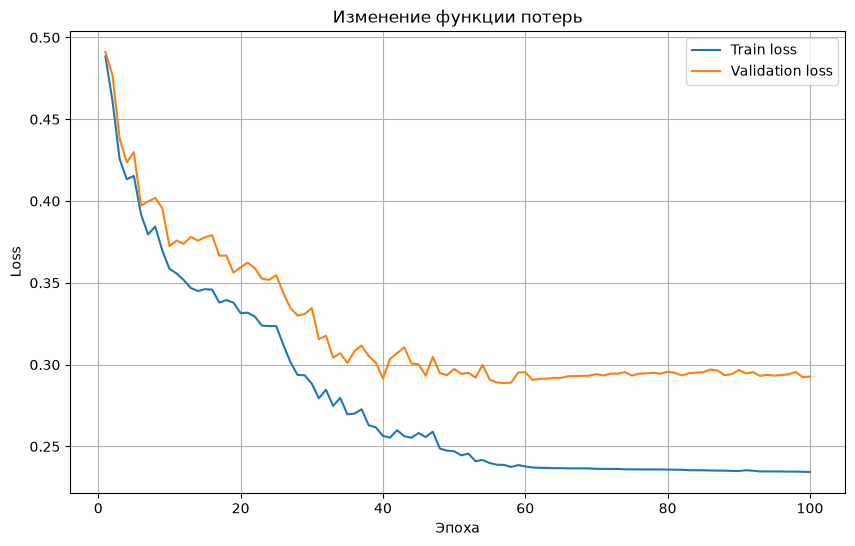

In [12]:
import matplotlib.pyplot as plt


def graphic():
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        train_loss,
        label='Train loss'
    )

    plt.plot(
        epochs,
        valid_loss,
        label='Validation loss'
    )

    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title('Изменение функции потерь')
    plt.legend()
    plt.grid()
    plt.show()


graphic()


Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

In [13]:
net = Network([784, 70, 10], alpha=3.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha35.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[145   5   0   1   5   2   1   0   0   1]
 [  8 152   0   0   0   0   0   0   0   0]
 [ 31   8   0   4  36  45   1   2  10  23]
 [ 50   5   0   5  47  31  12   1   2   7]
 [  4   0   0   1 153   2   0   0   0   0]
 [  1   2   0   0   1 156   0   0   0   0]
 [ 45  27   0   1  17  61   4   0   1   4]
 [ 52   9   0   1  26  62   1   0   1   8]
 [ 43  14   0   2  49  23   8   6   1  14]
 [ 44  62   0   0  11  39   2   0   0   2]]

Classification report:
              precision    recall  f1-score   support

           0       0.34      0.91      0.50       160
           1       0.54      0.95      0.68       160
           2       0.00      0.00      0.00       160
           3       0.33      0.03      0.06       160
           4       0.44      0.96      0.61       160
           5       0.37      0.97      0.54       160
           6   

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

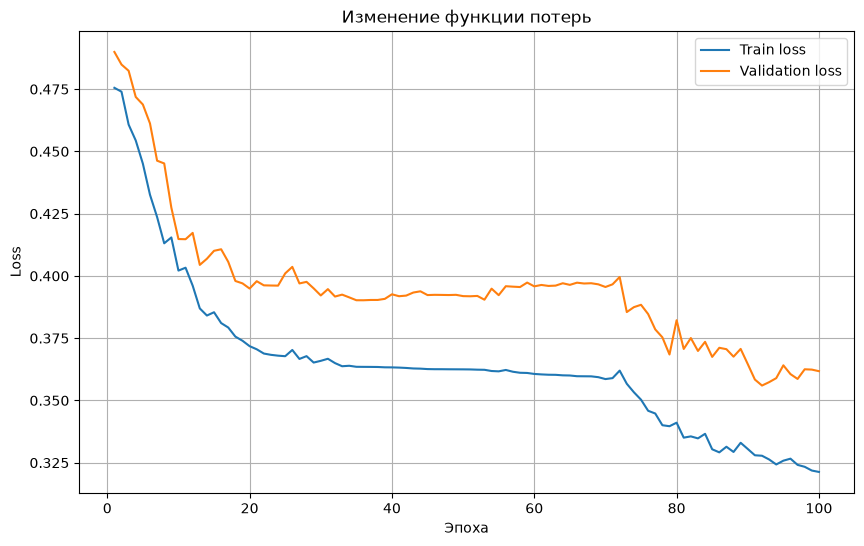

In [14]:
graphic()

In [15]:

net = Network([784, 70, 10], alpha=4.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha45.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[ 10   9  24  40   6   1  48   2   5  15]
 [ 42   1  21   0  14   4  74   0   2   2]
 [  0   0 152   5   0   0   3   0   0   0]
 [  0   0   7 151   0   0   2   0   0   0]
 [ 10   0   6 116   0   0  21   0   0   7]
 [  2   4   2  61   6   0  71   0   1  13]
 [  6   1   4   4   0   0 144   0   0   1]
 [  3   6   9 107   1   0  13   4   0  17]
 [ 15   3   6  42   2   1  78   3   0  10]
 [  4   2  31  23  14   1  71   2   8   4]]

Classification report:
              precision    recall  f1-score   support

           0       0.11      0.06      0.08       160
           1       0.04      0.01      0.01       160
           2       0.58      0.95      0.72       160
           3       0.28      0.94      0.43       160
           4       0.00      0.00      0.00       160
           5       0.00      0.00      0.00       160
           6   

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

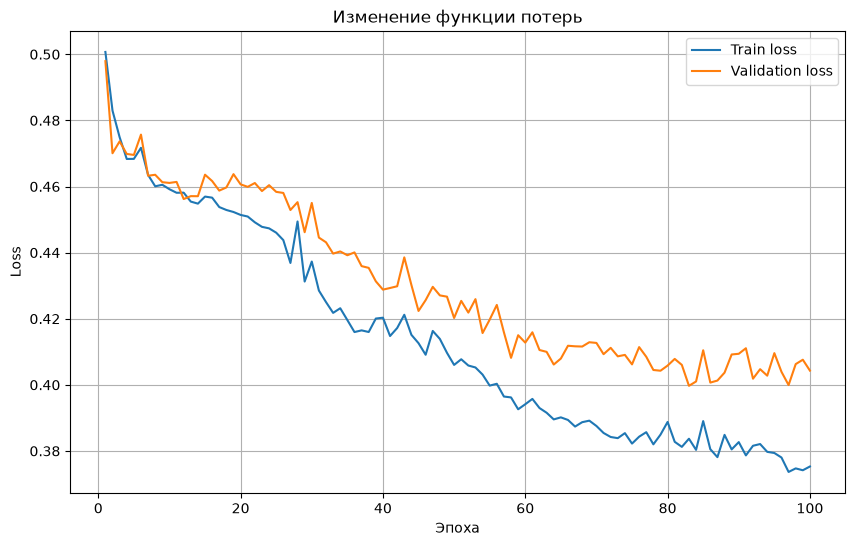

In [16]:
graphic()

## Реализация и возможности нейронной сети

Для реализации многослойного перцептрона (MLP) используется библиотека PyTorch, предоставляющая инструменты для создания, обучения и оценки нейронных сетей.

Класс `Network` описывает архитектуру нейронной сети. Количество нейронов в каждом слое задаётся параметром `sizes`, что позволяет создавать сети различной глубины и ширины. Между скрытыми слоями используются линейные преобразования, пользовательская сигмоидальная функция активации `CustomSigmoid` и слой `Dropout`, снижающий риск переобучения. Выходной слой формирует значения для каждого классифицируемого класса. Метод `predict()` применяет Softmax для преобразования выходных значений в вероятности принадлежности к классам.

Класс `CustomSigmoid` реализует сигмоидальную функцию активации с дополнительным параметром `alpha`, который регулирует её крутизну. Это позволяет изменять характер нелинейного преобразования, выполняемого в скрытых слоях сети.

Класс `NetworkWork` отвечает за процесс обучения и оценку результатов. В методе `early_stopping()` исходная обучающая выборка разделяется на обучающую и валидационную части в соотношении 80/20. Для обучения данные разбиваются на мини-пакеты размером 32 объекта, которые перемешиваются перед каждой эпохой. На каждом шаге вычисляется функция потерь, выполняется обратное распространение ошибки и обновляются параметры модели с помощью выбранного оптимизатора.

Для предотвращения переобучения применяется Early Stopping. После каждой эпохи рассчитывается ошибка на валидационной выборке. Если она уменьшается, текущие параметры модели сохраняются как лучшие. Если ошибка не улучшается в течение заданного количества эпох (`patience`), обучение прекращается, а модель восстанавливает параметры с наименьшей валидационной ошибкой.

Возможности:

- **Сохранение и загрузка модели.** Метод `save_work()` сохраняет обученные параметры, историю ошибок и информацию об использованных настройках. Метод `load_save()` позволяет загрузить сохранённые параметры и историю обучения.
- **Анализ процесса обучения.** Метод `output_info()` выводит номер эпохи с минимальной валидационной ошибкой, значения ошибок на обучающей и валидационной выборках, а также информацию о последних эпохах.
- **Построение графиков.** Метод `print_graphic()` отображает изменение ошибки на обучающей и валидационной выборках с помощью библиотеки Plotly. Это позволяет оценить сходимость модели и выявить возможные признаки переобучения.
- **Оценка качества классификации.** Метод `print_confusion()` выводит матрицы ошибок и отчёты классификации для обучающей и тестовой выборок. С их помощью можно оценить количество правильных и ошибочных предсказаний по каждому классу, а также показатели точности и полноты.
- **Поддержка разных функций потерь и оптимизаторов.** В зависимости от выбранной функции потерь обучение выполняется с соответствующей обработкой выходных значений модели. Это позволяет экспериментировать с различными вариантами обучения нейронной сети.

In [42]:
import torch
import torch.nn as nn
import plotly.graph_objects as go
import torch.optim as optim


class Network(nn.Module):
    def __init__(self, sizes, alpha=4, dropout=0.2, output=lambda x: torch.softmax(x, dim=1)):
        super().__init__()

        self.alpha = alpha
        self.output = output
        layers = []

        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(CustomSigmoid(alpha))
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(sizes[-2], sizes[-1]))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

    def predict(self, x):
        logits = self.forward(x)
        return self.output(logits)


class CustomSigmoid(nn.Module):
    def __init__(self, alpha=4):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return torch.sigmoid(self.alpha * x)


class NetworkWork():

    def __init__(self, model_torch, criterion, optimizer, max_epochs, patience, X_train_torch, y_train_torch,
                 output_fun=lambda x: torch.softmax(x, dim=1), output_name='softmax'):
        self.model_torch = model_torch
        self.criterion = criterion
        self.optimizer = optimizer
        self.max_epochs = max_epochs
        self.patience = patience
        self.X_train_torch = X_train_torch
        self.y_train_torch = y_train_torch
        self.train_losses = []
        self.val_losses = []
        self.output_fun = output_fun
        self.output_name = output_name

    def early_stopping(self):

        X_train_torch_part, X_val_torch, \
            y_train_torch_part, y_val_torch = train_test_split(
            self.X_train_torch,
            self.y_train_torch,
            test_size=0.2,
            random_state=42,
            stratify=self.y_train_torch
        )

        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                X_train_torch_part,
                y_train_torch_part
            ),
            batch_size=32,
            shuffle=True
        )

        best_val_loss = float('inf')
        best_model = None
        epochs_without_improvement = 0

        for epoch in range(self.max_epochs):
            # Обучение
            self.model_torch.train()

            epoch_loss = 0.0

            for X_batch, y_batch in train_loader:

                self.optimizer.zero_grad()

                if self.criterion.__class__.__name__ == 'CrossEntropyLoss':
                    output = self.model_torch(X_batch)

                    loss = self.criterion(
                        output,
                        y_batch
                    )
                else:
                    output = self.output_fun(
                        self.model_torch(X_batch)
                    )
                    loss = self.criterion(
                        output,
                        y_batch
                    )
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()

            train_loss = epoch_loss / len(train_loader)
            self.train_losses.append(train_loss)

            # Валидация
            self.model_torch.eval()

            with torch.no_grad():

                if self.criterion.__class__.__name__ == 'CrossEntropyLoss':
                    val_output = self.model_torch(X_val_torch)

                    val_loss = self.criterion(
                        val_output,
                        y_val_torch
                    )
                else:
                    val_output = self.output_fun(
                        self.model_torch(X_val_torch)
                    )
                    val_loss = self.criterion(
                        val_output,
                        y_val_torch
                    )
            val_loss = val_loss.item()

            self.val_losses.append(val_loss)

            # Early Stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = {
                    key: value.clone()
                    for key, value in self.model_torch.state_dict().items()
                }
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                print("Early stopping на эпохе:", epoch + 1)
                break
        self.model_torch.load_state_dict(best_model)

    def output_info(self):
        best_epoch = np.argmin(self.val_losses)

        print("Оптимальная эпоха:", best_epoch + 1)
        print("Минимальный Validation Loss:", self.val_losses[best_epoch])
        print("Train Loss в оптимальной точке:", self.train_losses[best_epoch])

        print("Количество эпох обучения:", len(self.train_losses))

        last_n = min(20, len(self.train_losses))

        print(f"\nПоследние {last_n} эпох:")
        print("Эпоха | Train Loss | Validation Loss")
        print("-" * 40)

        for i in range(len(self.train_losses) - last_n, len(self.train_losses)):
            print(
                f"{i + 1:5d} | "
                f"{self.train_losses[i]:10.6f} | "
                f"{self.val_losses[i]:15.6f}"
            )

    def print_graphic(self, title):
        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                y=self.train_losses,
                mode='lines',
                name='Обучающая выборка'
            )
        )

        fig.add_trace(
            go.Scatter(
                y=self.val_losses,
                mode='lines',
                name='Валидационная выборка'
            )
        )

        fig.update_layout(
            title=title,
            xaxis_title='Эпоха',
            yaxis_title='Loss'
        )

        fig.show()

    def print_confusion(self, y_train, y_test, pred_train_torch, pred_test_torch, MODEL_FILE):
        print(MODEL_FILE)
        print("Матрица ошибок — PyTorch MLP — Train:")
        print(confusion_matrix(y_train, pred_train_torch))

        print("\nClassification Report — PyTorch MLP — Train:")
        print(classification_report(y_train, pred_train_torch))

        print("\nМатрица ошибок — PyTorch MLP — Test:")
        print(confusion_matrix(y_test, pred_test_torch))

        print("\nClassification Report — PyTorch MLP — Test:")
        print(classification_report(y_test, pred_test_torch))

    def save_work(self, MODEL_FILE):
        torch.save({
            'model_state': self.model_torch.state_dict(),

            'train_losses': self.train_losses,
            'val_losses': self.val_losses,

            'max_epochs': self.max_epochs,
            'patience': self.patience,

            'criterion': self.criterion.__class__.__name__,
            'optimizer': self.optimizer.__class__.__name__,
            'output': self.output_name
        }, MODEL_FILE)

    def work(self, MODEL_FILE, X_test_torch, y_train, y_test):
        if self.load_save(MODEL_FILE):
            print("Модель загружена из файла.")
        else:
            self.early_stopping()
            self.save_work(MODEL_FILE)
            print("Модель обучена и сохранена.")

        self.output_info()
        self.print_graphic(MODEL_FILE)

        self.model_torch.eval()

        with torch.no_grad():

            pred_train_torch = torch.argmax(
                self.model_torch(self.X_train_torch),
                dim=1
            ).cpu().numpy()

            pred_test_torch = torch.argmax(
                self.model_torch(X_test_torch),
                dim=1
            ).cpu().numpy()

        self.print_confusion(
            y_train,
            y_test,
            pred_train_torch,
            pred_test_torch,
            MODEL_FILE
        )

    def load_save(self, MODEL_FILE):
        if os.path.exists(MODEL_FILE):
            data_model = torch.load(
                MODEL_FILE,
                weights_only=False
            )

            saved_output = data_model.get('output', 'softmax')
            current_output = self.output_name

            if saved_output != current_output:
                print("Функция выхода изменилась. Модель будет обучена заново.")
                return False

            self.model_torch.load_state_dict(data_model['model_state'])
            self.train_losses = data_model['train_losses']
            self.val_losses = data_model['val_losses']

            return True

        return False


### Подготовка данных для обучения

Перед обучением нейронной сети данные преобразуются в тензоры PyTorch с помощью `torch.tensor()`. Это необходимо для выполнения математических операций, вычисления градиентов и обновления весов нейронной сети.

Для входных признаков (`X_train`, `X_val`, `X_test`) используется тип `torch.float32`, поскольку вычисления внутри полносвязных слоёв выполняются с вещественными числами.

Метки классов преобразуются в тип `torch.long`, который требуется функции потерь `CrossEntropyLoss`. Для функции `MSELoss` дополнительно создаются метки в формате one-hot с типом `torch.float32`, где каждый класс представлен отдельным элементом вектора.

In [18]:
X_train_torch = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_torch = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_torch = torch.tensor(
    X_test,
    dtype=torch.float32
)

# Метки классов для CrossEntropyLoss
y_train_torch = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_torch = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_torch = torch.tensor(
    y_test,
    dtype=torch.long
)

# One-hot метки для MSELoss
y_train_mse_torch = torch.tensor(
    y_train_onehot,
    dtype=torch.float32
)

y_val_mse_torch = torch.tensor(
    y_val_onehot,
    dtype=torch.float32
)

In [19]:
MODEL_FILE = 'CEAdam.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=100,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 23
Минимальный Validation Loss: 0.46214455366134644
Train Loss в оптимальной точке: 0.1833857089281082
Количество эпох обучения: 43

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   24 |   0.171987 |        0.469526
   25 |   0.160895 |        0.482879
   26 |   0.161783 |        0.463195
   27 |   0.148172 |        0.463961
   28 |   0.133945 |        0.468713
   29 |   0.140597 |        0.471581
   30 |   0.137255 |        0.484971
   31 |   0.130609 |        0.466007
   32 |   0.124111 |        0.473087
   33 |   0.120308 |        0.472084
   34 |   0.115242 |        0.469886
   35 |   0.109936 |        0.466098
   36 |   0.102203 |        0.474599
   37 |   0.098536 |        0.480414
   38 |   0.090822 |        0.466599
   39 |   0.100979 |        0.478370
   40 |   0.088507 |        0.487284
   41 |   0.088136 |        0.472860
   42 |   0.084655 |        0.478047
   43 |   0.079386 | 

CEAdam.pth
Матрица ошибок — PyTorch MLP — Train:
[[156   1   0   2   0   0   0   1   0   0]
 [  1 158   0   0   0   0   1   0   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  1   0   3 156   0   0   0   0   0   0]
 [  0   0   0   1 157   0   1   1   0   0]
 [  0   0   0   1   2 152   0   2   0   3]
 [  2   2   2   1   2   0 148   0   0   3]
 [  0   1   0   1   0   2   2 151   0   3]
 [  0   0   1   0   2   0   3   0 154   0]
 [  1   4   0   0   0   1   2   5   4 143]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       160
           1       0.95      0.99      0.97       160
           2       0.96      0.97      0.97       160
           3       0.94      0.97      0.96       160
           4       0.96      0.98      0.97       160
           5       0.98      0.95      0.97       160
           6       0.94      0.93      0.93       160
           7       0.94      0.94      0.

In [20]:
MODEL_FILE = 'MSEAdam.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=100,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 100
Минимальный Validation Loss: 0.026278646662831306
Train Loss в оптимальной точке: 0.018295221030712128
Количество эпох обучения: 100

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   81 |   0.023149 |        0.028572
   82 |   0.022675 |        0.028423
   83 |   0.022520 |        0.028277
   84 |   0.022314 |        0.028143
   85 |   0.022584 |        0.028006
   86 |   0.021819 |        0.027872
   87 |   0.021598 |        0.027737
   88 |   0.021207 |        0.027596
   89 |   0.020799 |        0.027462
   90 |   0.021111 |        0.027319
   91 |   0.020882 |        0.027187
   92 |   0.020100 |        0.027065
   93 |   0.020736 |        0.026943
   94 |   0.020244 |        0.026832
   95 |   0.019758 |        0.026732
   96 |   0.019533 |        0.026628
   97 |   0.019633 |        0.026533
   98 |   0.019553 |        0.026444
   99 |   0.019104 |        0.026360
  100 |   0.0182

MSEAdam.pth
Матрица ошибок — PyTorch MLP — Train:
[[145   1   1   3   0   0   2   4   1   3]
 [  3 156   0   0   0   0   1   0   0   0]
 [  0   0 154   4   1   1   0   0   0   0]
 [  3   0   7 145   1   1   1   1   1   0]
 [  0   0   6   1 149   1   1   0   2   0]
 [  0   2   0   1   2 148   2   1   0   4]
 [  1   4   1   0   2   0 142   0   6   4]
 [  1   1   2   1   0  10   1 141   1   2]
 [  0   2   1   0   3   1   7   0 146   0]
 [  3  14   0   0   2   3   4   5   6 123]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.87      0.97      0.92       160
           2       0.90      0.96      0.93       160
           3       0.94      0.91      0.92       160
           4       0.93      0.93      0.93       160
           5       0.90      0.93      0.91       160
           6       0.88      0.89      0.88       160
           7       0.93      0.88      0

In [21]:
MODEL_FILE = 'CESGD.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.612585186958313
Train Loss в оптимальной точке: 0.545355012267828
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.550107 |        0.620985
  482 |   0.549439 |        0.620662
  483 |   0.554929 |        0.620162
  484 |   0.555656 |        0.619833
  485 |   0.541932 |        0.619394
  486 |   0.545167 |        0.619113
  487 |   0.555386 |        0.618629
  488 |   0.542562 |        0.618170
  489 |   0.545101 |        0.617766
  490 |   0.543628 |        0.617161
  491 |   0.534241 |        0.616817
  492 |   0.551523 |        0.616240
  493 |   0.539124 |        0.615944
  494 |   0.543035 |        0.615461
  495 |   0.543912 |        0.614920
  496 |   0.540806 |        0.614381
  497 |   0.541859 |        0.613971
  498 |   0.546129 |        0.613673
  499 |   0.534685 |        0.613126
  500 |   0.545355 |  

CESGD.pth
Матрица ошибок — PyTorch MLP — Train:
[[143   3   1   2   0   1   0   3   5   2]
 [  4 150   0   0   0   0   3   0   0   3]
 [  0   0 153   6   1   0   0   0   0   0]
 [  3   0   8 143   1   2   1   1   1   0]
 [  1   0   4   1 148   1   2   1   2   0]
 [  0   3   0   1   4 139   3   6   0   4]
 [  2   7   2   0   3   1 132   0   7   6]
 [  3   1   1   2   0   6   2 143   0   2]
 [  1   2   1   0   3   0   6   0 147   0]
 [  6  20   0   0   1   4   8   7   5 109]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       160
           1       0.81      0.94      0.87       160
           2       0.90      0.96      0.93       160
           3       0.92      0.89      0.91       160
           4       0.92      0.93      0.92       160
           5       0.90      0.87      0.89       160
           6       0.84      0.82      0.83       160
           7       0.89      0.89      0.8

In [22]:
MODEL_FILE = 'MSESGD.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.1
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 374
Минимальный Validation Loss: 0.020470552146434784
Train Loss в оптимальной точке: 0.010663293220568448
Количество эпох обучения: 394

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  375 |   0.010063 |        0.020525
  376 |   0.010295 |        0.020496
  377 |   0.010247 |        0.020490
  378 |   0.010214 |        0.020527
  379 |   0.010277 |        0.020504
  380 |   0.010575 |        0.020562
  381 |   0.009682 |        0.020585
  382 |   0.010122 |        0.020540
  383 |   0.009680 |        0.020587
  384 |   0.010106 |        0.020642
  385 |   0.009526 |        0.020620
  386 |   0.010193 |        0.020602
  387 |   0.010007 |        0.020539
  388 |   0.010259 |        0.020560
  389 |   0.009880 |        0.020563
  390 |   0.010345 |        0.020531
  391 |   0.010633 |        0.020565
  392 |   0.009838 |        0.020510
  393 |   0.009763 |        0.020544
  394 |   0.0100

MSESGD.pth
Матрица ошибок — PyTorch MLP — Train:
[[148   1   0   3   0   1   1   5   1   0]
 [  2 156   0   0   0   0   1   1   0   0]
 [  0   0 154   5   1   0   0   0   0   0]
 [  1   0   4 152   1   1   0   0   1   0]
 [  1   0   2   0 152   1   1   2   1   0]
 [  0   1   0   0   1 154   2   1   0   1]
 [  0   2   0   1   1   0 149   0   4   3]
 [  0   0   0   2   0   5   1 145   2   5]
 [  0   0   1   0   3   1   3   0 152   0]
 [  3   4   0   0   1   3   2   4   4 139]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.95      0.97      0.96       160
           2       0.96      0.96      0.96       160
           3       0.93      0.95      0.94       160
           4       0.95      0.95      0.95       160
           5       0.93      0.96      0.94       160
           6       0.93      0.93      0.93       160
           7       0.92      0.91      0.

![image.png](img.png)

Источник:https://deeplearningnotes.com/neural-networks/gradient-descent/nesterov-momentum
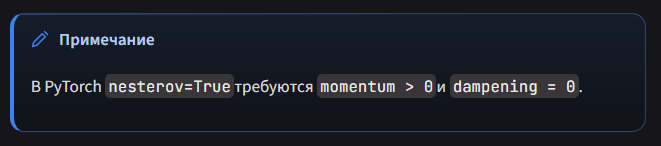
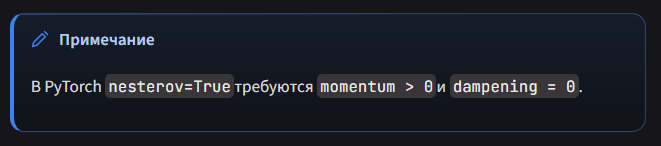

In [23]:
MODEL_FILE = 'CESGD_nesterov.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 238
Минимальный Validation Loss: 0.47600802779197693
Train Loss в оптимальной точке: 0.18561719348654152
Количество эпох обучения: 258

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  239 |   0.182055 |        0.476996
  240 |   0.189343 |        0.476487
  241 |   0.178393 |        0.479386
  242 |   0.165913 |        0.477644
  243 |   0.189278 |        0.479268
  244 |   0.175595 |        0.478854
  245 |   0.180574 |        0.477692
  246 |   0.171950 |        0.481156
  247 |   0.178453 |        0.479648
  248 |   0.173223 |        0.478080
  249 |   0.165245 |        0.477518
  250 |   0.181367 |        0.479313
  251 |   0.165687 |        0.478067
  252 |   0.180320 |        0.480536
  253 |   0.172003 |        0.479737
  254 |   0.168032 |        0.479760
  255 |   0.174244 |        0.480940
  256 |   0.165956 |        0.476507
  257 |   0.172161 |        0.478016
  258 |   0.165970

CESGD_nesterov.pth
Матрица ошибок — PyTorch MLP — Train:
[[154   1   0   3   0   0   0   1   0   1]
 [  2 157   0   0   0   0   1   0   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  1   0   4 155   0   0   0   0   0   0]
 [  0   0   0   2 156   0   1   1   0   0]
 [  0   0   0   2   1 154   0   0   0   3]
 [  1   2   1   1   2   0 148   0   2   3]
 [  1   0   0   1   0   5   1 148   2   2]
 [  1   0   1   1   1   0   0   0 156   0]
 [  1   5   0   0   0   2   2   3   4 143]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       160
           1       0.95      0.98      0.97       160
           2       0.96      0.97      0.97       160
           3       0.92      0.97      0.94       160
           4       0.97      0.97      0.97       160
           5       0.96      0.96      0.96       160
           6       0.97      0.93      0.95       160
           7       0.97      0.93

In [24]:
MODEL_FILE = 'MSESGD_nesterov.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.04240177944302559
Train Loss в оптимальной точке: 0.04218429415486753
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.043687 |        0.043580
  482 |   0.042672 |        0.043518
  483 |   0.043422 |        0.043455
  484 |   0.042511 |        0.043390
  485 |   0.042572 |        0.043326
  486 |   0.042631 |        0.043267
  487 |   0.042644 |        0.043206
  488 |   0.042515 |        0.043142
  489 |   0.042838 |        0.043079
  490 |   0.042135 |        0.043018
  491 |   0.042159 |        0.042953
  492 |   0.042111 |        0.042892
  493 |   0.041718 |        0.042829
  494 |   0.042094 |        0.042767
  495 |   0.042160 |        0.042709
  496 |   0.042076 |        0.042646
  497 |   0.042043 |        0.042586
  498 |   0.041965 |        0.042526
  499 |   0.041863 |        0.042462
  500 |   0.042184

MSESGD_nesterov.pth
Матрица ошибок — PyTorch MLP — Train:
[[141   6   1   2   1   1   0   4   4   0]
 [  3 154   0   0   0   0   2   1   0   0]
 [  0   0 152   7   1   0   0   0   0   0]
 [  3   1  16 132   4   1   0   2   1   0]
 [  1   0   5   4 143   3   2   0   2   0]
 [  1   4   1   1   2 133   5  13   0   0]
 [  8  18   2   4   4   3 108   0  11   2]
 [  3   3   6   1   0  12   2 133   0   0]
 [  1   1   1   1   2   0   4   0 150   0]
 [  8  75   7   0   1  13  11  14  10  21]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       160
           1       0.59      0.96      0.73       160
           2       0.80      0.95      0.87       160
           3       0.87      0.82      0.85       160
           4       0.91      0.89      0.90       160
           5       0.80      0.83      0.82       160
           6       0.81      0.68      0.73       160
           7       0.80      0.8

In [25]:
MODEL_FILE = 'CESGDm.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 222
Минимальный Validation Loss: 0.4765354096889496
Train Loss в оптимальной точке: 0.19615078549832105
Количество эпох обучения: 242

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  223 |   0.198725 |        0.479518
  224 |   0.207193 |        0.477249
  225 |   0.196714 |        0.477708
  226 |   0.193566 |        0.479709
  227 |   0.189442 |        0.480825
  228 |   0.180725 |        0.481392
  229 |   0.184517 |        0.480551
  230 |   0.185715 |        0.479178
  231 |   0.191528 |        0.478909
  232 |   0.190318 |        0.480341
  233 |   0.193949 |        0.480853
  234 |   0.183401 |        0.479350
  235 |   0.193691 |        0.480275
  236 |   0.185072 |        0.483190
  237 |   0.190272 |        0.479146
  238 |   0.182787 |        0.479348
  239 |   0.181587 |        0.480889
  240 |   0.180196 |        0.481496
  241 |   0.185372 |        0.483749
  242 |   0.178241 

CESGDm.pth
Матрица ошибок — PyTorch MLP — Train:
[[156   1   0   1   0   0   0   1   1   0]
 [  2 157   0   0   0   0   1   0   0   0]
 [  0   0 157   3   0   0   0   0   0   0]
 [  1   0   4 155   0   0   0   0   0   0]
 [  0   0   0   2 156   0   1   1   0   0]
 [  0   0   0   2   2 154   0   0   0   2]
 [  1   2   0   2   3   0 149   0   1   2]
 [  0   1   0   1   0   6   1 147   1   3]
 [  1   0   1   0   2   0   0   0 156   0]
 [  1   6   0   0   0   2   3   6   4 138]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       160
           1       0.94      0.98      0.96       160
           2       0.97      0.98      0.98       160
           3       0.93      0.97      0.95       160
           4       0.96      0.97      0.97       160
           5       0.95      0.96      0.96       160
           6       0.96      0.93      0.95       160
           7       0.95      0.92      0.

In [47]:
MODEL_FILE = 'MSESGDm.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.04486187919974327
Train Loss в оптимальной точке: 0.04343574494123459
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.044735 |        0.046255
  482 |   0.044868 |        0.046180
  483 |   0.044774 |        0.046106
  484 |   0.044588 |        0.046029
  485 |   0.044591 |        0.045951
  486 |   0.044958 |        0.045878
  487 |   0.044392 |        0.045805
  488 |   0.044749 |        0.045731
  489 |   0.044128 |        0.045655
  490 |   0.044319 |        0.045583
  491 |   0.044207 |        0.045506
  492 |   0.044345 |        0.045433
  493 |   0.043980 |        0.045362
  494 |   0.044381 |        0.045288
  495 |   0.044239 |        0.045213
  496 |   0.043857 |        0.045144
  497 |   0.043816 |        0.045075
  498 |   0.043109 |        0.045004
  499 |   0.043593 |        0.044932
  500 |   0.043436

MSESGDm.pth
Матрица ошибок — PyTorch MLP — Train:
[[142   5   1   5   0   1   1   4   1   0]
 [  3 153   0   0   0   1   3   0   0   0]
 [  0   0 154   5   1   0   0   0   0   0]
 [  4   0  16 132   2   2   1   2   1   0]
 [  0   0   7   3 143   2   3   0   2   0]
 [  0   4   2   0   2 140   4   8   0   0]
 [  5  15   3   3   3   5 117   0   9   0]
 [  6   3   8   3   0  11   2 127   0   0]
 [  1   1   1   1   4   0   6   0 146   0]
 [ 17  79   3   0   1   7  12  10   8  23]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       160
           1       0.59      0.96      0.73       160
           2       0.79      0.96      0.87       160
           3       0.87      0.82      0.85       160
           4       0.92      0.89      0.91       160
           5       0.83      0.88      0.85       160
           6       0.79      0.73      0.76       160
           7       0.84      0.79      0

## Архитектура свёрточной нейронной сети (CNN)

Источник построения сети: [Neurohive](https://neurohive.io/ru/tutorial/cnn-na-pytorch).

Нейронная сеть `ConvNet` предназначена для классификации изображений рукописных букв по 10 классам. Архитектура состоит из двух основных частей: свёрточного блока, который извлекает признаки изображения, и полносвязного блока, который использует извлечённые признаки для определения класса буквы.

Свёрточные нейронные сети (CNN) — это специализированный класс искусственных нейронных сетей, разработанный для задач, где важна пространственная структура данных, например, обработка изображений или видео.

Свёртка — это процесс, где небольшое ядро (фильтр) скользит по изображению и вычисляет новые значения, выделяя локальные признаки.

Первый слой `Conv2d(1, 32, kernel_size=5, stride=1, padding=2)` выполняет свёрточное преобразование входного изображения. Параметры слоя определяют количество входных и выходных каналов, размер фильтров и способ их перемещения по изображению.

- `1` — количество входных каналов. Канал представляет собой отдельную двумерную матрицу значений пикселей. 1 канал, так как ч/б изображение.
- `32` — количество выходных каналов, то есть число фильтров, используемых слоем.
- `kernel_size=5` — размер ядра свёртки.
- `stride=1` — шаг перемещения фильтра, равный одному пикселю.
- `padding=2` — добавление двух рядов и двух столбцов дополнительных значений по краям изображения с каждой стороны.

В результате первый свёрточный слой формирует 32 карты признаков размером 28х28. Карта признаков — это базовый результат обработки входного изображения или предыдущего слоя свёрточным фильтром внутри нейросети. В задачах компьютерного зрения (CV) такие карты служат внутренним представлением данных и выделяют определённые закономерности, например края, текстуры или сложные геометрические формы, распознавать которые научилась модель

После свёртки применяется слой `CustomSigmoid(alpha)`.

Далее применяется слой `MaxPool2d(kernel_size=2, stride=2)`, где
- kernel_size – размер окна, по которому выполняется максимизация.
- stride – шаг окна.

Второй свёрточный слой `Conv2d(32, 64, kernel_size=5, stride=1, padding=2)` принимает 32 карты признаков, сформированные предыдущим слоем, и создаёт 64 новые карты признаков.

Поскольку слой имеет 64 фильтра, он формирует 64 карты признаков размером 14х14. После этого снова применяются `CustomSigmoid(alpha)` и `MaxPool2d(kernel_size=2, stride=2)`. Максимальная подвыборка уменьшает ширину и высоту каждой карты в два раза — до 7х7.

Таким образом, после двух свёрточных слоёв и двух операций Max Pooling получается тензор размером (64х7х7) для каждого изображения. Он содержит признаки, извлечённые из исходной буквы.

Перед передачей данных в полносвязную часть сети вызывается функция `torch.flatten(x, start_dim=1)`. Она объединяет все значения карт признаков в один вектор для каждого изображения.

Первый полносвязный слой `Linear(7 * 7 * 64, 70)` получает вектор из 3136 признаков и преобразует его в 70 выходных значений.

Полносвязный слой связывает каждый входной признак с каждым выходным нейроном. Для вычисления каждого выходного значения входы умножаются на соответствующие обучаемые веса, суммируются, после чего добавляется обучаемое смещение.

Количество выходных нейронов равно 70. Это означает, что слой преобразует 3136 исходных признаков в более компактное представление из 70 значений. Благодаря этому полносвязная часть может объединять признаки, найденные свёрточными слоями, и использовать их совместно для классификации.

После линейного преобразования применяется `CustomSigmoid(alpha)`. Она преобразует каждое из 70 значений в диапазон от 0 до 1 и вносит нелинейность в полносвязную часть сети.

In [27]:
class ConvNet(nn.Module):
    def __init__(self, alpha=4, dropout=0.2):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            CustomSigmoid(alpha),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            CustomSigmoid(alpha),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layers = nn.Sequential(
            nn.Linear(7 * 7 * 64, 70),
            CustomSigmoid(alpha),
            nn.Dropout(dropout),
            nn.Linear(70, 10)
        )

    def forward(self, x):
        if x.ndim == 2:
            x = x.reshape(-1, 1, 28, 28)
        elif x.ndim == 3:
            x = x.unsqueeze(1)

        x = self.conv_layers(x)
        x = torch.flatten(x, start_dim=1)
        x = self.layers(x)

        return x


In [50]:
MODEL_FILE = 'CNN_CEAdam.pth'

net = ConvNet(alpha=4, dropout=0.2)

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.0003,
        eps=1e-7,
        weight_decay=1e-4
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 108
Минимальный Validation Loss: 0.17303535342216492
Train Loss в оптимальной точке: 0.009797560097649694
Количество эпох обучения: 128

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  109 |   0.009012 |        0.185312
  110 |   0.008718 |        0.186442
  111 |   0.009224 |        0.174822
  112 |   0.008470 |        0.185484
  113 |   0.008265 |        0.181163
  114 |   0.008489 |        0.190480
  115 |   0.008335 |        0.185863
  116 |   0.007322 |        0.180931
  117 |   0.006848 |        0.183151
  118 |   0.007589 |        0.185910
  119 |   0.008044 |        0.198358
  120 |   0.008527 |        0.188856
  121 |   0.007730 |        0.176450
  122 |   0.007672 |        0.181279
  123 |   0.007554 |        0.183790
  124 |   0.007982 |        0.179487
  125 |   0.007171 |        0.180167
  126 |   0.006598 |        0.179273
  127 |   0.006042 |        0.175326
  128 |   0.00637

CNN_CEAdam.pth
Матрица ошибок — PyTorch MLP — Train:
[[159   0   0   1   0   0   0   0   0   0]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 158   1   0   0   0   0   0   1]
 [  0   0   2 158   0   0   0   0   0   0]
 [  0   0   0   2 158   0   0   0   0   0]
 [  0   0   0   0   0 158   0   0   0   2]
 [  0   0   1   0   0   0 158   0   0   1]
 [  0   0   0   1   0   0   0 157   0   2]
 [  0   0   1   0   0   0   1   0 158   0]
 [  0   0   0   0   0   0   0   0   0 160]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       160
           1       1.00      1.00      1.00       160
           2       0.98      0.99      0.98       160
           3       0.97      0.99      0.98       160
           4       1.00      0.99      0.99       160
           5       1.00      0.99      0.99       160
           6       0.99      0.99      0.99       160
           7       1.00      0.98    

In [29]:
MODEL_FILE = 'CNN_MSEAdam.pth'

net = ConvNet(alpha=4, dropout=0.2)

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.0003,
        eps=1e-7,
        weight_decay=1e-4
    ),
    max_epochs=100,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 95
Минимальный Validation Loss: 0.007956926710903645
Train Loss в оптимальной точке: 0.0015798699358128942
Количество эпох обучения: 100

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   81 |   0.001381 |        0.009060
   82 |   0.001330 |        0.008709
   83 |   0.001704 |        0.008939
   84 |   0.001500 |        0.008250
   85 |   0.001620 |        0.007957
   86 |   0.001202 |        0.009374
   87 |   0.001211 |        0.008327
   88 |   0.001627 |        0.008988
   89 |   0.001140 |        0.008633
   90 |   0.001442 |        0.008726
   91 |   0.001511 |        0.008055
   92 |   0.001373 |        0.008331
   93 |   0.001093 |        0.008117
   94 |   0.001101 |        0.009048
   95 |   0.001580 |        0.007957
   96 |   0.001176 |        0.008529
   97 |   0.001200 |        0.008494
   98 |   0.001218 |        0.008230
   99 |   0.001203 |        0.008659
  100 |   0.0009

CNN_MSEAdam.pth
Матрица ошибок — PyTorch MLP — Train:
[[158   1   0   1   0   0   0   0   0   0]
 [  0 159   0   0   0   0   0   1   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  0   0   3 157   0   0   0   0   0   0]
 [  0   0   0   0 157   0   2   1   0   0]
 [  0   0   0   0   1 159   0   0   0   0]
 [  0   0   0   0   0   0 160   0   0   0]
 [  0   0   0   0   0   0   1 158   0   1]
 [  0   0   1   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   1   1   0 158]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       160
           1       0.99      0.99      0.99       160
           2       0.97      0.97      0.97       160
           3       0.97      0.98      0.98       160
           4       0.99      0.98      0.99       160
           5       1.00      0.99      1.00       160
           6       0.98      1.00      0.99       160
           7       0.98      0.99   

In [30]:
MODEL_FILE = 'CNN_CESGD.pth'

net = ConvNet(alpha=4, dropout=0.2)

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.4320865571498871
Train Loss в оптимальной точке: 0.37008504532277586
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.393668 |        0.444007
  482 |   0.390866 |        0.443818
  483 |   0.381683 |        0.441906
  484 |   0.381139 |        0.442181
  485 |   0.378904 |        0.441482
  486 |   0.380886 |        0.440058
  487 |   0.378940 |        0.439924
  488 |   0.383709 |        0.438955
  489 |   0.379416 |        0.439232
  490 |   0.377113 |        0.438554
  491 |   0.379866 |        0.438207
  492 |   0.374829 |        0.437320
  493 |   0.373845 |        0.436773
  494 |   0.369532 |        0.437668
  495 |   0.376888 |        0.435552
  496 |   0.381968 |        0.435952
  497 |   0.374215 |        0.434247
  498 |   0.378226 |        0.435215
  499 |   0.377652 |        0.433895
  500 |   0.370085 

CNN_CESGD.pth
Матрица ошибок — PyTorch MLP — Train:
[[147   3   1   2   0   0   0   1   3   3]
 [  3 157   0   0   0   0   0   0   0   0]
 [  0   0 154   4   1   0   0   0   0   1]
 [  2   0   7 148   1   1   1   0   0   0]
 [  0   0   1   2 151   1   3   1   1   0]
 [  0   0   0   1   3 146   3   2   0   5]
 [  4   3   2   0   3   1 139   0   4   4]
 [  0   0   1   1   0   3   4 147   0   4]
 [  3   0   1   0   1   0   5   0 149   1]
 [  2  12   0   0   1   2   4   7   4 128]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       160
           1       0.90      0.98      0.94       160
           2       0.92      0.96      0.94       160
           3       0.94      0.93      0.93       160
           4       0.94      0.94      0.94       160
           5       0.95      0.91      0.93       160
           6       0.87      0.87      0.87       160
           7       0.93      0.92     

In [31]:
MODEL_FILE = 'CNN_MSESGD.pth'

net = ConvNet(alpha=4, dropout=0.2)

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.1
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 388
Минимальный Validation Loss: 0.010019625537097454
Train Loss в оптимальной точке: 0.0036366284984978847
Количество эпох обучения: 408

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  389 |   0.003633 |        0.010369
  390 |   0.003581 |        0.010369
  391 |   0.003393 |        0.010164
  392 |   0.003480 |        0.010176
  393 |   0.003599 |        0.010481
  394 |   0.003477 |        0.010028
  395 |   0.003458 |        0.010241
  396 |   0.003368 |        0.010099
  397 |   0.003684 |        0.010160
  398 |   0.003438 |        0.010181
  399 |   0.003540 |        0.010047
  400 |   0.003263 |        0.010429
  401 |   0.003380 |        0.010378
  402 |   0.003373 |        0.010387
  403 |   0.003356 |        0.010176
  404 |   0.003194 |        0.010233
  405 |   0.003240 |        0.010264
  406 |   0.003242 |        0.010156
  407 |   0.003383 |        0.010233
  408 |   0.003

CNN_MSESGD.pth
Матрица ошибок — PyTorch MLP — Train:
[[153   0   0   3   0   1   0   1   0   2]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  0   0   3 156   0   0   0   1   0   0]
 [  0   0   0   0 158   0   1   0   0   1]
 [  0   0   0   0   1 157   2   0   0   0]
 [  0   0   0   0   1   0 157   0   1   1]
 [  1   1   0   1   0   0   1 153   1   2]
 [  0   0   1   0   1   0   0   0 158   0]
 [  1   0   0   0   1   2   1   5   2 148]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       160
           1       0.99      1.00      1.00       160
           2       0.97      0.97      0.97       160
           3       0.95      0.97      0.96       160
           4       0.98      0.99      0.98       160
           5       0.98      0.98      0.98       160
           6       0.97      0.98      0.98       160
           7       0.96      0.96    

In [32]:
MODEL_FILE = 'CNN_CESGD_nesterov.pth'

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 90
Минимальный Validation Loss: 0.12751181423664093
Train Loss в оптимальной точке: 0.06034170002676546
Количество эпох обучения: 110

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   91 |   0.063737 |        0.133167
   92 |   0.060461 |        0.128264
   93 |   0.061082 |        0.130527
   94 |   0.056592 |        0.132732
   95 |   0.059863 |        0.130120
   96 |   0.061508 |        0.130718
   97 |   0.057201 |        0.129077
   98 |   0.055424 |        0.128710
   99 |   0.059065 |        0.135301
  100 |   0.055309 |        0.131672
  101 |   0.059688 |        0.130146
  102 |   0.054879 |        0.130025
  103 |   0.054437 |        0.129281
  104 |   0.056542 |        0.128187
  105 |   0.053757 |        0.128900
  106 |   0.051219 |        0.130309
  107 |   0.054327 |        0.127716
  108 |   0.052420 |        0.130898
  109 |   0.047135 |        0.131165
  110 |   0.051561 

CNN_CESGD_nesterov.pth
Матрица ошибок — PyTorch MLP — Train:
[[159   0   0   1   0   0   0   0   0   0]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 159   1   0   0   0   0   0   0]
 [  0   0   2 158   0   0   0   0   0   0]
 [  0   0   0   0 159   0   1   0   0   0]
 [  0   0   0   0   1 159   0   0   0   0]
 [  0   0   0   0   1   0 158   0   0   1]
 [  0   0   0   1   0   2   0 154   0   3]
 [  0   0   1   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   0   0   0 160]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       160
           1       1.00      1.00      1.00       160
           2       0.98      0.99      0.99       160
           3       0.98      0.99      0.98       160
           4       0.99      0.99      0.99       160
           5       0.99      0.99      0.99       160
           6       0.99      0.99      0.99       160
           7       1.00      

In [33]:
MODEL_FILE = 'CNN_MSESGD_nesterov.pth'

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 1
Минимальный Validation Loss: 0.004043367225676775
Train Loss в оптимальной точке: 0.0018663033337361413
Количество эпох обучения: 21

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
    2 |   0.001924 |        0.004054
    3 |   0.001988 |        0.004071
    4 |   0.001838 |        0.004088
    5 |   0.002129 |        0.004102
    6 |   0.001890 |        0.004103
    7 |   0.001857 |        0.004115
    8 |   0.001752 |        0.004114
    9 |   0.001899 |        0.004132
   10 |   0.001984 |        0.004139
   11 |   0.001896 |        0.004140
   12 |   0.001937 |        0.004153
   13 |   0.001858 |        0.004160
   14 |   0.001918 |        0.004147
   15 |   0.001737 |        0.004142
   16 |   0.002046 |        0.004155
   17 |   0.001742 |        0.004168
   18 |   0.001729 |        0.004171
   19 |   0.001805 |        0.004177
   20 |   0.001912 |        0.004175
   21 |   0.001794

CNN_MSESGD_nesterov.pth
Матрица ошибок — PyTorch MLP — Train:
[[159   0   0   1   0   0   0   0   0   0]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 159   1   0   0   0   0   0   0]
 [  0   0   2 158   0   0   0   0   0   0]
 [  0   0   0   0 159   0   1   0   0   0]
 [  0   0   0   0   1 159   0   0   0   0]
 [  0   0   0   0   1   0 158   0   0   1]
 [  0   0   0   1   0   2   0 154   0   3]
 [  0   0   1   0   0   0   0   0 159   0]
 [  0   0   0   0   0   0   0   0   0 160]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       160
           1       1.00      1.00      1.00       160
           2       0.98      0.99      0.99       160
           3       0.98      0.99      0.98       160
           4       0.99      0.99      0.99       160
           5       0.99      0.99      0.99       160
           6       0.99      0.99      0.99       160
           7       1.00     

In [34]:
MODEL_FILE = 'CNN_CESGDm.pth'

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 8
Минимальный Validation Loss: 0.12711715698242188
Train Loss в оптимальной точке: 0.05500108425039798
Количество эпох обучения: 28

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
    9 |   0.060379 |        0.129622
   10 |   0.054891 |        0.130928
   11 |   0.053972 |        0.129315
   12 |   0.054798 |        0.129811
   13 |   0.055350 |        0.129434
   14 |   0.057979 |        0.129648
   15 |   0.054411 |        0.129884
   16 |   0.055162 |        0.127240
   17 |   0.049571 |        0.128399
   18 |   0.051551 |        0.130175
   19 |   0.050497 |        0.131503
   20 |   0.051944 |        0.129430
   21 |   0.055322 |        0.127897
   22 |   0.050423 |        0.130590
   23 |   0.050825 |        0.128616
   24 |   0.048119 |        0.130697
   25 |   0.048074 |        0.127396
   26 |   0.048273 |        0.129533
   27 |   0.046912 |        0.128611
   28 |   0.048252 | 

CNN_CESGDm.pth
Матрица ошибок — PyTorch MLP — Train:
[[158   0   0   1   0   0   0   1   0   0]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 159   1   0   0   0   0   0   0]
 [  0   0   2 158   0   0   0   0   0   0]
 [  0   0   0   0 159   0   1   0   0   0]
 [  0   0   0   0   1 159   0   0   0   0]
 [  0   0   0   0   1   0 158   0   0   1]
 [  0   0   0   1   0   2   0 154   0   3]
 [  0   0   1   0   1   0   0   0 158   0]
 [  0   0   0   0   0   0   0   0   0 160]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       160
           1       1.00      1.00      1.00       160
           2       0.98      0.99      0.99       160
           3       0.98      0.99      0.98       160
           4       0.98      0.99      0.99       160
           5       0.99      0.99      0.99       160
           6       0.99      0.99      0.99       160
           7       0.99      0.96    

In [35]:
MODEL_FILE = 'CNN_MSESGDm.pth'

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 2
Минимальный Validation Loss: 0.00398671068251133
Train Loss в оптимальной точке: 0.001988039591560664
Количество эпох обучения: 22

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
    3 |   0.001933 |        0.004006
    4 |   0.001781 |        0.004016
    5 |   0.001553 |        0.004025
    6 |   0.001610 |        0.004030
    7 |   0.001777 |        0.004021
    8 |   0.001994 |        0.004031
    9 |   0.001677 |        0.004042
   10 |   0.001849 |        0.004041
   11 |   0.001567 |        0.004046
   12 |   0.001805 |        0.004050
   13 |   0.001817 |        0.004059
   14 |   0.001925 |        0.004069
   15 |   0.001841 |        0.004069
   16 |   0.002028 |        0.004056
   17 |   0.001641 |        0.004049
   18 |   0.001859 |        0.004045
   19 |   0.001673 |        0.004042
   20 |   0.001675 |        0.004054
   21 |   0.001639 |        0.004045
   22 |   0.001727 |

CNN_MSESGDm.pth
Матрица ошибок — PyTorch MLP — Train:
[[158   0   0   1   0   0   0   1   0   0]
 [  0 160   0   0   0   0   0   0   0   0]
 [  0   0 159   1   0   0   0   0   0   0]
 [  0   0   2 158   0   0   0   0   0   0]
 [  0   0   0   0 159   0   1   0   0   0]
 [  0   0   0   0   1 159   0   0   0   0]
 [  0   0   0   0   1   0 158   0   0   1]
 [  0   0   0   1   0   2   0 154   0   3]
 [  0   0   1   0   1   0   0   0 158   0]
 [  0   0   0   0   0   0   0   0   0 160]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       160
           1       1.00      1.00      1.00       160
           2       0.98      0.99      0.99       160
           3       0.98      0.99      0.98       160
           4       0.98      0.99      0.99       160
           5       0.99      0.99      0.99       160
           6       0.99      0.99      0.99       160
           7       0.99      0.96   

Функция активации:![image.png](img_1.png)

(x) — входное значение, (alpha) — коэффициент, изменяющий крутизну сигмоиды стоит при -x.

Источник: https://docs.pytorch.org/docs/2.14/generated/torch.nn.Sigmoid.html

Линейная функция: ![image.png](img_2.png)

**Значения параметров:**

- `x` — входной вектор или матрица входных данных;
- `A` — матрица обучаемых весов;
- `A^T` — транспонированная матрица весов;
- `b` — вектор смещений;
- `y` — результат линейного преобразования.

Источник: https://docs.pytorch.org/docs/2.14/generated/torch.nn.Linear.html

Функция оптимизации СГД: ![image.png](img_3.png)

**Значения параметров:**

- `ω(t+1)` — обновлённый вектор весов (параметров модели) на следующем шаге `t+1`;
- `ω(t)` — текущий вектор весов на шаге `t`;
- `ηt` — скорость обучения (learning rate) на шаге `t`;
- `l` — количество примеров (или размер мини-батча), по которым суммируются градиенты;
- `∇Li(ω(t), xi)` — градиент функции потерь `L` для `i`-го примера `xi` при текущих весах `ω(t)`;
- `xi` — входной вектор или матрица входных данных `i`-го примера.

Источник: https://proproprogs.ru/ml/ml-stohasticheskiy-gradientnyy-spusk-sgd-i-algoritm-sag

Функция оптимизации СГД с импульсом: ![image.png](img_4.png)

**Значения параметров:**

- `u_t` — вектор импульса на текущем шаге обучения, определяющий величину и направление обновления параметров;
- `u_(t-1)` — вектор импульса на предыдущем шаге;
- `γ` — коэффициент импульса, определяющий влияние предыдущих обновлений (обычно `0.9`);
- `η_t` — скорость обучения на шаге `t`, определяющая размер шага при обновлении параметров;
- `∇loss(θ)` — градиент функции потерь по параметрам модели `θ`, показывающий направление наиболее быстрого увеличения ошибки;
- `θ` — текущие параметры нейронной сети (веса и смещения);
- `t` — номер шага обучения.


Источник: https://proproprogs.ru/neural_network/tf-stroim-gradientnye-algoritmy-optimizacii-adam-rmsprop-adagrad-adadelta

Функция оптимизации СГД с импульсом Нестерова: ![image.png](img_5.png)

**Значения параметров:**

- `u_t` — вектор импульса на текущем шаге;
- `u_(t-1)` — вектор импульса на предыдущем шаге;
- `γ` — коэффициент импульса, определяющий влияние предыдущего обновления;
- `η_t` — скорость обучения на шаге `t`;
- `∇loss(θ - γu_(t-1))` — градиент функции потерь, вычисленный в точке предварительного смещения параметров с учётом предыдущего импульса;
- `θ` — текущие параметры нейронной сети;
- `t` — номер шага обучения.

Источник: https://proproprogs.ru/neural_network/tf-stroim-gradientnye-algoritmy-optimizacii-adam-rmsprop-adagrad-adadelta

Функция оптимизации Адам:![image.png](img_6.png)

**Значения параметров:**

- `m_t` — экспоненциальное скользящее среднее градиентов, используемое для определения направления обновления параметров;
- `m_(t-1)` — значение скользящего среднего градиентов на предыдущем шаге;
- `v_t` — экспоненциальное скользящее среднее квадратов градиентов, используемое для адаптивной настройки величины обновления параметров;
- `v_(t-1)` — значение скользящего среднего квадратов градиентов на предыдущем шаге;
- `β_1` — коэффициент сглаживания первого момента, обычно `0.9`;
- `β_2` — коэффициент сглаживания второго момента, обычно `0.999`;
- `g_t` — градиент функции потерь по параметрам модели на текущем шаге;
- `g_t²` — квадрат градиента, вычисляемый поэлементно;
- `η` — скорость обучения, определяющая масштаб обновления параметров;
- `ε` — малое положительное число для обеспечения численной стабильности при делении;
- `u_t` — величина изменения параметров модели на текущем шаге;
- `√v_t` — квадратный корень из скользящего среднего квадратов градиентов, вычисляемый поэлементно.

Источник: https://proproprogs.ru/neural_network/tf-stroim-gradientnye-algoritmy-optimizacii-adam-rmsprop-adagrad-adadelta

Функция потерь Cross Entropy Loss: ![image.png](img_7.png)

**Значения параметров:**

- `CE` — значение кросс-энтропийной функции потерь;
- `N` — количество примеров в выборке или батче;
- `C` — количество классов;
- `i` — индекс примера;
- `j` — индекс класса;
- `y(i,j)` — истинная метка: `1`, если `i`-й пример принадлежит `j`-му классу, иначе `0`;
- `p(i,j)` — предсказанная моделью вероятность принадлежности `i`-го примера к `j`-му классу;
- `log` — натуральный логарифм.

Источник: https://www.geeksforgeeks.org/machine-learning/what-is-cross-entropy-loss-function/

Функция потерь MSELoss: ![image.png](img_8.png)

**Значения параметров:**

- `MSE` — среднеквадратичная ошибка;
- `n` — количество элементов, по которым вычисляется ошибка;
- `i` — индекс элемента;
- `y_i` — истинное целевое значение;
- `ŷ_i` — предсказанное моделью значение;
- `ŷ_i - y_i` — разница между истинным и предсказанным значениями;
- `(ŷ_i - y_i)^2` — квадрат ошибки отдельного элемента.

Источник: https://codingnomads.com/mean-squared-error-loss-function

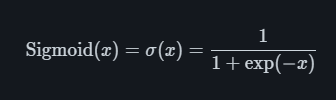
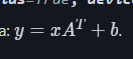
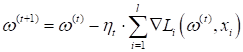
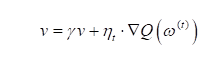
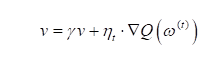
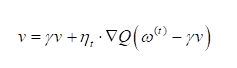
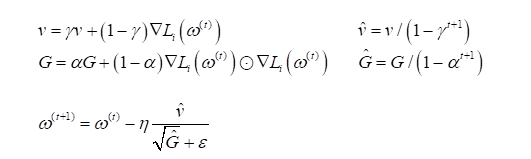
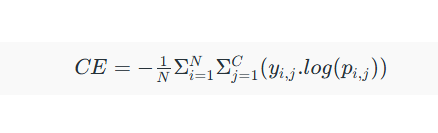
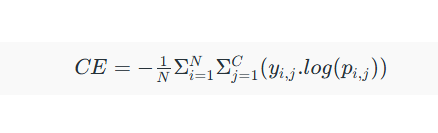
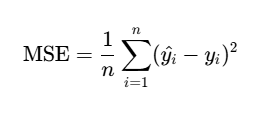
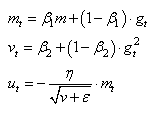
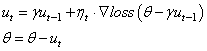
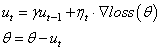
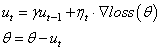

В формуле Адам: Параметры beta1 и beta2 управляют скоростью затухания оценок моментов. Как правило, beta1 устанавливается на значение, близкое к 1 (например, 0,9), что означает, что оценка первого момента имеет долгую память и обеспечивает хорошую оценку тренда градиента. С другой стороны, beta2 устанавливается на гораздо меньшее значение (например, 0,999), что означает, что оценка второго момента имеет более короткую память и больше фокусируется на величине градиента.

Источник: https://medium.com/@devapatlakirankumar/getting-to-know-adam-optimization-a-comprehensive-guide-3d63b9f6d514

## 1. Сравнение реализаций MLP

| Модель | Оптимизатор | Accuracy на обучении | Accuracy на тесте | Macro F1 на тесте |
|---|---|---:|---:|---:|
| CEAdam | Adam | 96% | 87% | 0,87 |
| MSEAdam | Adam | 91% | 85% | 0,85 |
| CESGD | SGD | 88% | 84% | 0,84 |
| MSESGD | SGD | 94% | 87% | 0,87 |
| CESGD + Nesterov | SGD + Nesterov | 95% | 87% | 0,87 |
| MSESGD + Nesterov | SGD + Nesterov | 79% | 78% | 0,75 |
| CESGDm | SGD с импульсом | 95% | 88% | 0,88 |
| MSESGDm | SGD с импульсом | 80% | 77% | 0,74 |

Среди реализаций MLP лучший результат показала CESGDm с SGD и импульсом: точность на тестовой выборке составила 88%, а Macro F1 — 0,88. Модели с `CrossEntropyLoss` в целом показали более стабильные результаты. Наименее эффективными оказались варианты с `MSELoss` и импульсом Нестерова или обычным импульсом, особенно при распознавании класса 9.

## 2. Сравнение CNN

| Модель | Оптимизатор | Accuracy на обучении | Accuracy на тесте | Macro F1 на тесте |
|---|---|---:|---:|---:|
| CNN_CEAdam | Adam | 99% | 95% | 0,95 |
| CNN_MSEAdam | Adam | 99% | 94% | 0,94 |
| CNN_CESGD | SGD | 92% | 89% | 0,89 |
| CNN_MSESGD | SGD | 97% | 93% | 0,93 |
| CNN_CESGD + Nesterov | SGD + Nesterov | 99% | 94% | 0,94 |
| CNN_MSESGD + Nesterov | SGD + Nesterov | 99% | 94% | 0,94 |
| CNN_CESGDm | SGD с импульсом | 99% | 94% | 0,94 |
| CNN_MSESGDm | SGD с импульсом | 99% | 94% | 0,94 |

CNN показала более высокую точность, чем MLP: лучший результат составил 95% против 88%. Наиболее эффективной оказалась CNN_CEAdam, использующая `CrossEntropyLoss` и оптимизатор Adam. Она достигла Macro F1 = 0,95, что указывает на высокое качество классификации по всем классам. Остальные варианты CNN также показали хорошие результаты — от 89% до 94% точности на тестовой выборке.

In [54]:
MODEL_FILE = 'MSESGDm_tanh.pth'

net = Network([784, 70, 10], output=torch.tanh)

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=torch.tanh,
    output_name='tanh'
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)
MODEL_FILE = 'MSESGDm_sigmoid.pth'

net = Network([784, 70, 10], output=torch.sigmoid)

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=torch.sigmoid,
    output_name='sigmoid'

)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)
MODEL_FILE = 'MSESGD_tanh.pth'

net = Network([784, 70, 10], output=torch.tanh)

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=torch.tanh,
    output_name='tanh'
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)
MODEL_FILE = 'CESGD_tanh.pth'

net = Network([784, 70, 10], output=torch.tanh)

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=torch.tanh,
    output_name='tanh'
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)
MODEL_FILE = 'MSESGD_ReLU.pth'

net = Network([784, 70, 10], output=nn.ReLU())

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=nn.ReLU(),
    output_name='ReLU'
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)
MODEL_FILE = 'CESGD_ReLU.pth'

net = Network([784, 70, 10], output=nn.ReLU())

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch,
    output_fun=nn.ReLU(),
    output_name='ReLU'
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.03488297387957573
Train Loss в оптимальной точке: 0.03379830056801438
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.034690 |        0.035315
  482 |   0.034114 |        0.035293
  483 |   0.034139 |        0.035271
  484 |   0.034075 |        0.035237
  485 |   0.034137 |        0.035205
  486 |   0.033790 |        0.035184
  487 |   0.034920 |        0.035166
  488 |   0.033851 |        0.035150
  489 |   0.033928 |        0.035127
  490 |   0.034028 |        0.035097
  491 |   0.034333 |        0.035081
  492 |   0.034520 |        0.035056
  493 |   0.033751 |        0.035031
  494 |   0.034262 |        0.035009
  495 |   0.033937 |        0.034987
  496 |   0.033923 |        0.034965
  497 |   0.033925 |        0.034942
  498 |   0.034148 |        0.034924
  499 |   0.034463 |        0.034906
  500 |   0.033798

MSESGDm_tanh.pth
Матрица ошибок — PyTorch MLP — Train:
[[146   1   1   4   0   0   3   4   1   0]
 [  4 154   0   0   0   0   1   1   0   0]
 [  0   0 152   6   1   0   1   0   0   0]
 [  3   0   9 141   2   2   2   0   0   1]
 [  0   0   6   1 149   0   3   0   1   0]
 [  0   2   0   1   3 143   3   4   0   4]
 [  2   4   0   4   4   4 134   0   5   3]
 [  1   1   2   2   0   8   1 142   1   2]
 [  2   0   1   0   3   0   4   0 150   0]
 [  5  20   0   0   1   5   6   9   5 109]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       160
           1       0.85      0.96      0.90       160
           2       0.89      0.95      0.92       160
           3       0.89      0.88      0.88       160
           4       0.91      0.93      0.92       160
           5       0.88      0.89      0.89       160
           6       0.85      0.84      0.84       160
           7       0.89      0.89  

MSESGDm_sigmoid.pth
Матрица ошибок — PyTorch MLP — Train:
[[138   5   4   3   1   3   0   4   2   0]
 [  3 155   0   0   0   0   1   1   0   0]
 [  0   0 153   6   1   0   0   0   0   0]
 [  3   0  19 127   6   2   0   3   0   0]
 [  0   0   8   1 145   2   1   0   3   0]
 [  1   4   1   2   2 138   4   7   0   1]
 [  7  25   3   5   2   8  91   0  18   1]
 [  0   3   8   4   0  11   1 132   1   0]
 [  1   2   1   0   4   0   2   0 150   0]
 [  6  89   6   0   1  13   7  13  11  14]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       160
           1       0.55      0.97      0.70       160
           2       0.75      0.96      0.84       160
           3       0.86      0.79      0.82       160
           4       0.90      0.91      0.90       160
           5       0.78      0.86      0.82       160
           6       0.85      0.57      0.68       160
           7       0.82      0.8

MSESGD_tanh.pth
Матрица ошибок — PyTorch MLP — Train:
[[134   6   3   5   1   2   0   6   2   1]
 [  2 155   0   0   0   2   1   0   0   0]
 [  0   0 153   6   1   0   0   0   0   0]
 [  2   1  18 128   4   1   1   4   0   1]
 [  0   0   7   2 145   0   4   0   2   0]
 [  0   5   3   1   1 132   5  11   0   2]
 [  2  11   0   5   5   3 123   0   8   3]
 [  2   1   7   1   0  14   2 132   0   1]
 [  1   2   1   0   6   0   7   2 141   0]
 [  6  61   3   0   1   9  14   8   4  54]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       160
           1       0.64      0.97      0.77       160
           2       0.78      0.96      0.86       160
           3       0.86      0.80      0.83       160
           4       0.88      0.91      0.90       160
           5       0.81      0.82      0.82       160
           6       0.78      0.77      0.78       160
           7       0.81      0.82   

CESGD_tanh.pth
Матрица ошибок — PyTorch MLP — Train:
[[142   3   2   4   0   0   0   5   2   2]
 [  4 152   0   0   0   0   1   0   0   3]
 [  0   0 153   6   1   0   0   0   0   0]
 [  3   0   7 143   2   3   2   0   0   0]
 [  1   0   4   2 147   1   2   1   2   0]
 [  1   3   0   1   3 138   3   7   0   4]
 [  2   6   2   1   3   1 130   0   5  10]
 [  1   1   2   2   0  10   2 139   0   3]
 [  0   1   1   0   3   0   8   0 147   0]
 [  5  22   0   0   1   4   8   7   5 108]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       160
           1       0.81      0.95      0.87       160
           2       0.89      0.96      0.92       160
           3       0.90      0.89      0.90       160
           4       0.92      0.92      0.92       160
           5       0.88      0.86      0.87       160
           6       0.83      0.81      0.82       160
           7       0.87      0.87    

MSESGD_ReLU.pth
Матрица ошибок — PyTorch MLP — Train:
[[140   5   3   3   0   0   0   3   4   2]
 [  4 155   0   0   0   0   0   0   1   0]
 [  1   0 150   8   0   1   0   0   0   0]
 [  4   0  17 132   0   3   1   3   0   0]
 [  1   0   9  65   0   8  10   7  60   0]
 [  4   5   3   2   0 121   3  18   0   4]
 [  6  19   3   3   0   3 112   0  10   4]
 [  3   1   8   2   0  10   1 132   1   2]
 [  3   1   1   3   0   2   4   0 146   0]
 [  8  53   3   0   0   4   6   8   7  71]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       160
           1       0.65      0.97      0.78       160
           2       0.76      0.94      0.84       160
           3       0.61      0.82      0.70       160
           4       0.00      0.00      0.00       160
           5       0.80      0.76      0.78       160
           6       0.82      0.70      0.75       160
           7       0.77      0.82   

C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Daria\PycharmProjects\PythonProject\lab2networks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

CESGD_ReLU.pth
Матрица ошибок — PyTorch MLP — Train:
[[143   3   1   4   0   0   0   5   2   2]
 [  4 150   0   0   0   0   2   0   0   4]
 [  0   0 153   6   1   0   0   0   0   0]
 [  3   0   9 142   2   1   2   1   0   0]
 [  1   0   5   3 146   1   1   0   2   1]
 [  1   3   0   1   2 140   2   7   0   4]
 [  3   8   1   2   2   1 130   0   6   7]
 [  1   1   2   1   0  10   2 140   0   3]
 [  1   1   1   0   4   0   7   0 146   0]
 [  4  22   0   0   1   4   8   8   4 109]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       160
           1       0.80      0.94      0.86       160
           2       0.89      0.96      0.92       160
           3       0.89      0.89      0.89       160
           4       0.92      0.91      0.92       160
           5       0.89      0.88      0.88       160
           6       0.84      0.81      0.83       160
           7       0.87      0.88    